# Análisis del Desarrollo Educativo y la Finalización Escolar Femenina

## Introducción
El análisis de indicadores educativos es fundamental para comprender cómo evolucionan el acceso, la equidad y la permanencia escolar en distintos países. Diversos organismos internacionales han señalado que la finalización de la educación primaria constituye un punto crítico en el desarrollo humano, pues condiciona oportunidades futuras y refleja desigualdades persistentes (UNESCO, 2021; UNICEF, 2022). Estas brechas afectan especialmente a las niñas en contextos de vulnerabilidad, donde factores económicos y sociales limitan la continuidad escolar (World Bank, 2023).

Para este estudio se utilizan datos del **World Development Indicators (WDI)**, una base estadística global del Banco Mundial que reúne información armonizada, comparable entre países y actualizada anualmente. Su estructura estandarizada permite analizar tendencias de largo plazo y contrastar diferencias regionales con un alto nivel de confiabilidad (World Bank Data Group, 2022).

El indicador central analizado es **Primary completion rate, female (% of relevant age group)** (SE.PRM.CMPT.FE.ZS), que mide el porcentaje de niñas que completan la educación primaria dentro de la edad oficial. Su relevancia radica en que:

- refleja desigualdades de género en el progreso escolar,  
- permite evaluar la capacidad de los sistemas educativos para garantizar trayectorias completas,  
- se vincula a metas internacionales como los Objetivos de Desarrollo Sostenible (UNESCO, 2021),  
- señala barreras estructurales que afectan la permanencia escolar femenina.

El uso de WDI es adecuado para este análisis porque:

- sus datos están armonizados internacionalmente,  
- cuenta con series históricas amplias,  
- permite análisis descriptivos y comparaciones entre regiones,  
- es validado por organismos multilaterales, lo que aumenta su confiabilidad.

En conjunto, este estudio contribuye a identificar patrones recientes en la equidad educativa y a comprender los factores que favorecen o limitan el progreso de las niñas en el sistema escolar.

### Obtención y procesamiento de datos

Los datos utilizados en este análisis fueron extraídos directamente desde la base **World Development Indicators (WDI)** del Banco Mundial mediante una interfaz en Python que permite acceder a la API oficial. Esta herramienta facilita la descarga automatizada de series estadísticas, la selección de indicadores específicos y la definición de rangos temporales de interés, devolviendo los resultados en un formato estructurado adecuado para análisis tipo panel. 

El uso de esta interfaz garantiza que los valores obtenidos provienen de la versión más reciente y validada de WDI, evitando errores derivados de descargas manuales o conversiones inconsistentes. Además, permite incorporar metadatos relevantes —como información regional o clasificación de ingreso de los países— cuando estos son necesarios para comparaciones adicionales. De esta manera, el proceso de extracción de datos mantiene criterios de reproducibilidad, estandarización y coherencia metodológica, aspectos fundamentales para asegurar la calidad del análisis estadístico.

In [ ]:
%pip install wbdata 

In [3]:
import wbdata
import datetime

indicadores = {
    "SE.PRM.CMPT.FE.ZS": "female_completion"
}

# Rango de fechas
fecha_inicio = datetime.datetime(2000, 1, 1)
fecha_fin = datetime.datetime(2022, 1, 1)

df = wbdata.get_dataframe(indicadores, date=(fecha_inicio, fecha_fin))

df.head()


female_completion
country                     date                   
Africa Eastern and Southern 2022          70.935730
                            2021          71.491768
                            2020          70.187447
                            2019          69.208900
                            2018          68.506729

Al cargar la data, aparece como si todo fuera una sola columna por lo que procedemos a resetear el indice de la siguiente manera:

In [4]:
df = df.reset_index()
df.columns
df.head()

,country,date,female_completion
0,Africa Eastern and Southern,2022,70.935730
1,Africa Eastern and Southern,2021,71.491768
2,Africa Eastern and Southern,2020,70.187447
3,Africa Eastern and Southern,2019,69.208900
4,Africa Eastern and Southern,2018,68.506729


De esta forma es posible evidenciar ya corregido el dataframe, ahora bien vamos a renombrar las columnas para trabajar con ellas de manera mas facil

In [5]:
df.columns = ["pais", "anio", "tasa_fin"]
df.head()
df.shape

(6118, 3)

In [7]:
df.head(4)

,pais,anio,tasa_fin
0,Africa Eastern and Southern,2022,70.935730
1,Africa Eastern and Southern,2021,71.491768
2,Africa Eastern and Southern,2020,70.187447
3,Africa Eastern and Southern,2019,69.208900


A partir de la informacion de la estructura del dataset es posible observar que hay datos faltantes, pero primero eliminaremos las filas duplicadas si hay

In [8]:

df = df.drop_duplicates()
df.info()

<class 'wbdata.client.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pais      6118 non-null   object 
 1   anio      6118 non-null   object 
 2   tasa_fin  4062 non-null   float64
dtypes: float64(1), object(2)
memory usage: 143.5+ KB


En Dtype es posible identificar que de las 3 variables existentes en el Dataframe, la variable "anio" no es del tipo que le corresponde, las otras 2 si coinciden con su tipo de variable, por lo que haremos el respectivo cambio de variable

In [9]:
df["anio"] = df["anio"].astype("Int64")
df.dtypes

pais         object
anio          Int64
tasa_fin    float64
dtype: object

Vamos a dividir ahora nuestro df en 2, ya que la primera parte muestras agrupaciones regionales y bloques geograficos, y la segunda parte si se logran observar paises individuales y su informacion

In [10]:
df_1 = df.iloc[:1127]
df_2 = df.iloc[1127:]

In [11]:
df_1.info

<bound method DataFrame.info of                              pais  anio   tasa_fin
0     Africa Eastern and Southern  2022  70.935730
1     Africa Eastern and Southern  2021  71.491768
2     Africa Eastern and Southern  2020  70.187447
3     Africa Eastern and Southern  2019  69.208900
4     Africa Eastern and Southern  2018  68.506729
...                           ...   ...        ...
1122                        World  2004  82.195053
1123                        World  2003  81.392647
1124                        World  2002  80.556351
1125                        World  2001  79.945801
1126                        World  2000  78.769112

[1127 rows x 3 columns]>

In [12]:
df_2.info

<bound method DataFrame.info of              pais  anio   tasa_fin
1127  Afghanistan  2022        NaN
1128  Afghanistan  2021        NaN
1129  Afghanistan  2020        NaN
1130  Afghanistan  2019  69.613503
1131  Afghanistan  2018  70.630531
...           ...   ...        ...
6113     Zimbabwe  2004        NaN
6114     Zimbabwe  2003  91.379852
6115     Zimbabwe  2002  92.397690
6116     Zimbabwe  2001  97.191200
6117     Zimbabwe  2000        NaN

[4991 rows x 3 columns]>

Habiendo dividido el df, ahora eliminaremos las filas que tengan por lo menos un valor faltante y de esta manera pasaremos con nuestra EDA

In [13]:
data = df_2.dropna(axis=0)
data.shape

(3004, 3)

In [14]:
import pandas as pd

cols = data.columns

if "pais" in cols:
    country_col = "pais"
else:
    raise ValueError("No encuentro la columna de país")

if "anio" in cols:
    year_col = "anio"
else:
    raise ValueError("No encuentro la columna de anio")

objetivo_anios = list(range(2000, 2023))
n_anios = len(objetivo_anios)

df_win = (
    data.rename(columns={country_col: "pais", year_col: "anio"})
    .copy()
)

df_win["anio"] = pd.to_numeric(df_win["anio"], errors="coerce")

df_win = df_win[
    df_win["pais"].notna() &
    df_win["anio"].notna() &
    df_win["anio"].isin(objetivo_anios)
]

n_paises = df_win["pais"].nunique()

cob_por_pais = (
    df_win[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios")
)

cob_por_pais["frac_cobertura"] = (
    cob_por_pais["n_anios"] / n_anios
)

n_completos = (cob_por_pais["n_anios"] == n_anios).sum()

prop_completos = (
    n_completos / n_paises
    if n_paises > 0 else None
)


res_cob = {
    "paises_con_algun_dato": len(cob_por_pais),
    "anios_min": cob_por_pais["n_anios"].min(),
    "anios_p25": cob_por_pais["n_anios"].quantile(0.25),
    "anios_med": cob_por_pais["n_anios"].median(),
    "anios_p75": cob_por_pais["n_anios"].quantile(0.75),
    "anios_max": cob_por_pais["n_anios"].max(),
}

print("Países con al menos un dato (2000–2022):", n_paises)

print(
    "Países con cobertura completa (23 años):",
    n_completos,
    f"({100 * prop_completos:.1f}%)"
)

print(res_cob)

Países con al menos un dato (2000–2022): 192
Países con cobertura completa (23 años): 30 (15.6%)
{'paises_con_algun_dato': 192, 'anios_min': 1, 'anios_p25': 11.0, 'anios_med': 17.0, 'anios_p75': 21.0, 'anios_max': 23}


En el período 2000–2022 contamos con datos de 192 países, pero la cobertura es heterogénea: solo 30 países (15,6%) reportan la serie completa de 23 años, mientras que el resto presenta huecos. En términos de extensión temporal por país, el mínimo es de 1 año, el p25 es 11, la mediana es 17, el p75 es 21 y el máximo es 23. Estos resultados confirman que trabajamos con un panel desbalanceado; por ello, los análisis temporales y las comparaciones entre países deben considerar esta asimetría de cobertura (p. ej., restringiendo periodos comunes, reportando el número efectivo de observaciones o aplicando estrategias robustas frente a datos faltantes) para evitar sesgos en la interpretación.

In [85]:
conteo_por_pais = (
    df_win[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios_reportados")
    .sort_values(by=["n_anios_reportados", "pais"], ascending=[False, True])
)

print("\nConteo de años por país")
print(conteo_por_pais)


Conteo de años por país
                          pais  n_anios_reportados
2                      Algeria                  23
6                    Argentina                  23
10                  Azerbaijan                  23
24           Brunei Darussalam                  23
25                    Bulgaria                  23
..                         ...                 ...
151  Sint Maarten (Dutch part)                   2
31                      Canada                   1
88   Korea, Dem. People's Rep.                   1
113                     Monaco                   1
156                South Sudan                   1

[192 rows x 2 columns]


Antes de interpretar las distribuciones gráficas de las variables, es importante considerar una característica metodológica de los datos de WDI. La tasa de finalización primaria puede superar el 100% debido a la forma en que se calcula: el numerador contabiliza a todos los estudiantes que egresan del último grado de primaria, independientemente de su edad, mientras que el denominador corresponde únicamente a la población oficialmente asignada a ese nivel. La presencia de estudiantes en sobredad, subedad o con historial de repetición puede inflar el numerador, generando valores superiores al 100%. Por esta razón, identificamos y revisamos previamente las observaciones que exceden ese umbral y, para mejorar la claridad visual en los gráficos, trabajamos con una versión acotada de la variable en el rango 0–100, conservando la original para efectos de trazabilidad.

In [15]:

n_mayor_100 = (data["tasa_fin"] > 100).sum()

prop_mayor_100 = round((data["tasa_fin"] > 100).mean() * 100, 2)

max_tasa = data["tasa_fin"].max()

print("Observaciones > 100%:", n_mayor_100)
print("Porcentaje del total:", prop_mayor_100, "%")
print("Valor máximo observado:", round(max_tasa, 2), "%\n")

top_mayor_100 = (
    data[data["tasa_fin"] > 100]       
    .sort_values(by="tasa_fin", ascending=False)  
    [["pais", "anio", "tasa_fin"]]   
    .head(15)                          
)


top_mayor_100

Observaciones > 100%: 750
Porcentaje del total: 24.97 %
Valor máximo observado: 168.18 %



,pais,anio,tasa_fin
4123,Monaco,2016,168.181824
5015,Seychelles,2021,167.040359
5019,Seychelles,2017,155.304740
5291,St. Kitts and Nevis,2021,150.354614
5017,Seychelles,2019,140.858209
3927,Maldives,2005,135.657684
5687,Turkiye,2016,135.340073
5016,Seychelles,2020,133.499171
1538,Belarus,2002,132.858887
4955,Saudi Arabia,2012,131.846054


## Analisis Univariado

El análisis univariado tiene como propósito examinar cada variable por separado con el fin de comprender su comportamiento general antes de integrar comparaciones entre países o estudiar su evolución temporal. En esta etapa se describen las características básicas de cada columna del dataset data, incluyendo medidas de tendencia central, dispersión, rangos, distribución y presencia de valores extremos. Dado que la tasa de finalización primaria puede presentar valores superiores al 100% debido a la metodología utilizada por WDI, y con el fin de mejorar la interpretación visual de las distribuciones, los gráficos correspondientes emplean una versión acotada de la variable objetivo en el intervalo 0–100. Esta decisión no altera los valores originales, que se conservan para su documentación, pero facilita la lectura de los resultados y evita que valores atípicos dominen la escala gráfica.

Dado que los datos corresponden a un panel desbalanceado —donde algunos países reportan más años que otros—, estos resultados deben interpretarse como una descripción global del conjunto y no como comparaciones estrictas entre unidades. Sin embargo, esta inspección preliminar permite identificar patrones fundamentales y garantizar que las transformaciones posteriores del EDA se realicen sobre una base sólida y coherentemente presentada, manteniendo consistencia entre la preparación de los datos y las visualizaciones que la acompañan

           pais         anio     tasa_fin  tasa_fin_cap
count      3004       3004.0  3004.000000   3004.000000
unique      192         <NA>          NaN           NaN
top     Finland         <NA>          NaN           NaN
freq         23         <NA>          NaN           NaN
mean        NaN  2011.341877    88.719666     87.315272
std         NaN      6.55421    20.260171     18.859416
min         NaN       2000.0    12.187710     12.187710
25%         NaN       2006.0    84.203827     84.203827
50%         NaN       2012.0    96.282114     96.282114
75%         NaN       2017.0   100.000000    100.000000
max         NaN       2022.0   168.181824    100.000000
count    3004.000000
mean       87.315272
std        18.859416
min        12.187710
25%        84.203827
50%        96.282114
75%       100.000000
max       100.000000
Name: tasa_fin_cap, dtype: float64
0.01     22.416192
0.25     84.203827
0.50     96.282114
0.75    100.000000
0.99    100.000000
Name: tasa_fin_cap, dtype: flo

C:\Users\samit\AppData\Local\Temp\ipykernel_12256\2504952257.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tasa_fin_cap"] = data["tasa_fin"].clip(lower=0, upper=100)
c:\Users\samit\anaconda3\envs\dataviz_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


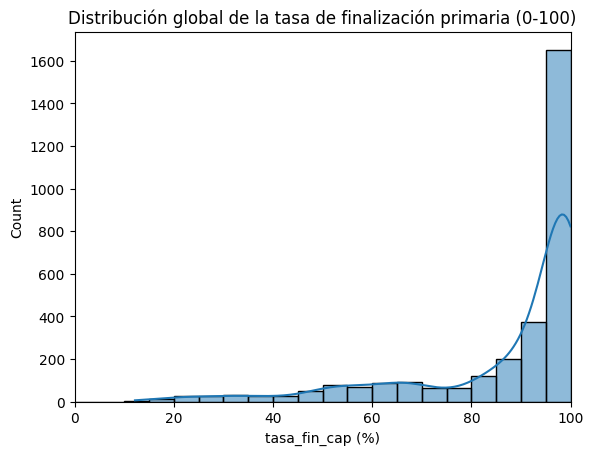

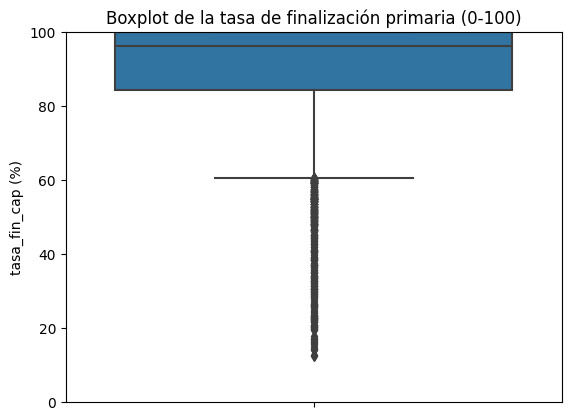

count         3004.0
mean     2011.341877
std          6.55421
min           2000.0
25%           2006.0
50%           2012.0
75%           2017.0
max           2022.0
Name: anio, dtype: Float64
(2000, 2022)


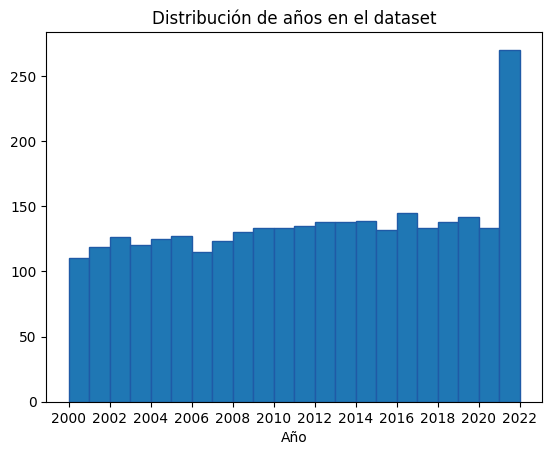

192
pais
Finland              23
Lithuania            23
Latvia               23
Brunei Darussalam    23
Bulgaria             23
Name: count, dtype: int64
pais
South Sudan                  1
Canada                       1
Monaco                       1
Korea, Dem. People's Rep.    1
Puerto Rico (US)             2
Sint Maarten (Dutch part)    2
Guinea-Bissau                2
Gabon                        2
Iraq                         3
Afghanistan                  4
Name: count, dtype: int64
pais
Slovak Republic    23
Malta              23
Madagascar         23
Azerbaijan         23
Mexico             23
Morocco            23
Norway             23
Argentina          23
Czechia            23
Finland            23
Name: count, dtype: int64


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

azul_main   = "#4A90E2"
azul_fuerte = "#1F5AA6"
gris_linea  = "#4D4D4D"
rojo_out    = "#D94E4E"

data["tasa_fin_cap"] = data["tasa_fin"].clip(lower=0, upper=100)

print(data.describe(include="all"))

print(data["tasa_fin_cap"].describe())
print(data["tasa_fin_cap"].quantile([0.01, 0.25, 0.5, 0.75, 0.99]))

plt.figure()
sns.histplot(data["tasa_fin_cap"], bins=np.arange(0, 105, 5), kde=True)

plt.title("Distribución global de la tasa de finalización primaria (0-100)")
plt.xlabel("tasa_fin_cap (%)")
plt.xlim(0, 100)

plt.show()

plt.figure()
sns.boxplot(y=data["tasa_fin_cap"])

plt.title("Boxplot de la tasa de finalización primaria (0-100)")
plt.ylabel("tasa_fin_cap (%)")
plt.ylim(0, 100)

plt.show()

print(data["anio"].describe())
print((data["anio"].min(), data["anio"].max()))

plt.figure()
plt.hist(data["anio"], bins=np.arange(2000, 2023, 1), edgecolor=azul_fuerte)

plt.title("Distribución de años en el dataset")
plt.xlabel("Año")

plt.xticks(np.arange(2000, 2023, 2)) 
plt.show()


print(data["pais"].nunique())

tabla_paises = data["pais"].value_counts()
print(tabla_paises.head())


print(tabla_paises.sort_values().head(10))
print(tabla_paises.sort_values().tail(10))

La inspección univariada del conjunto de datos revela tres patrones fundamentales. En primer lugar, la distribución de los años muestra que el período 2000–2022 está completamente cubierto, aunque la frecuencia de observaciones varía ligeramente entre años, reflejando la estructura desbalanceada del panel: algunos países aportan información de forma continua mientras otros presentan registros intermitentes. En segundo lugar, el boxplot de la tasa de finalización primaria (acotada al rango 0–100) evidencia que los valores se concentran en niveles altos, con una mediana cercana al 100%, pero también muestra una presencia notable de valores bajos y atípicos, indicando diferencias sustanciales en el desempeño educativo entre países. Finalmente, el histograma confirma visualmente este patrón: la distribución global es marcadamente asimétrica, con una fuerte acumulación de observaciones en torno a tasas elevadas y una cola hacia valores más bajos, lo que sugiere que, mientras muchos países alcanzan niveles altos de finalización primaria, un grupo significativo aún presenta rezagos importantes.

## Analisis bivariado

Antes de iniciar el análisis bivariado, dejamos constancia de que trabajaremos con la versión acotada de la variable objetivo (tasa_fin_cap ∈ [0,100]) para asegurar visualizaciones comparables y evitar que pocos valores extremos (>100%) distorsionen escalas y patrones; la variable original (tasa_fin) se conserva y, cuando sea pertinente (p. ej., para verificar robustez), contrastaremos resultados con ella. Dado que el panel es desbalanceado (cobertura desigual por país y año), en cada contraste reportaremos el número efectivo de observaciones y el rango temporal involucrado. Asimismo, al explorar asociaciones emplearemos medidas y gráficos robustos a asimetrías y acotamientos (p. ej., correlación de Spearman además de Pearson, y bandas intercuartílicas), dejando claro que las conclusiones se interpretan condicionadas al recorte a [0,100]. Esta decisión metodológica mejora la legibilidad y la coherencia del EDA, sin renunciar a la trazabilidad de la fuente original.

## Numerica vs Categorica

In [90]:
conteo = (
    data[["pais", "anio"]]
    .drop_duplicates()
    .groupby("pais")
    .size()
    .reset_index(name="n_anios")
)

df_completo_paises = conteo[conteo["n_anios"] == 23]["pais"]

df_top = data[data["pais"].isin(df_completo_paises)].copy()

print("Número de países con datos completos:", df_top["pais"].nunique())

Número de países con datos completos: 30


In [ ]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_top,
    x="tasa_fin_cap",
    y="pais",
    color=azul_main
)

# Mediana
medianas = df_top.groupby("pais")["tasa_fin_cap"].median().reset_index()

plt.scatter(
    medianas["tasa_fin_cap"],
    medianas["pais"],
    color=azul_fuerte,
    s=30
)

plt.xlim(0, 100)

plt.title("tasa_fin_cap por país (panel balanceado 2000–2022)")
plt.xlabel("tasa_fin_cap (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

c:\Users\dmarins\AppData\Local\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\dmarins\AppData\Local\miniconda3\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


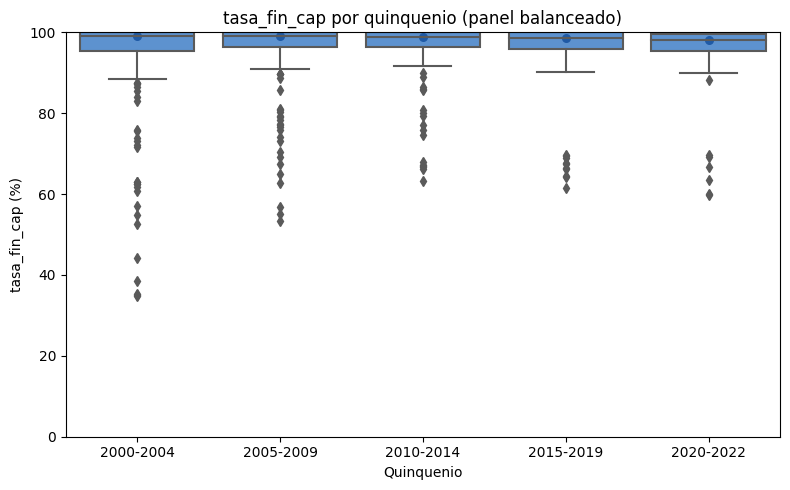

In [ ]:
df_q = df_top[
    (df_top["anio"] >= 2000) & (df_top["anio"] <= 2022)
].copy()

def quinquenio(anio):
    if anio <= 2004:
        return "2000-2004"
    elif anio <= 2009:
        return "2005-2009"
    elif anio <= 2014:
        return "2010-2014"
    elif anio <= 2019:
        return "2015-2019"
    else:
        return "2020-2022"

df_q["quinquenio"] = df_q["anio"].apply(quinquenio)

orden = ["2000-2004", "2005-2009", "2010-2014", "2015-2019", "2020-2022"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_q,
    x="quinquenio",
    y="tasa_fin_cap",
    order=orden,
    color=azul_main
)

medianas_q = df_q.groupby("quinquenio")["tasa_fin_cap"].median().reindex(orden)

plt.scatter(
    range(len(orden)),
    medianas_q,
    color=azul_fuerte,
    s=30
)

plt.ylim(0, 100)

plt.title("tasa_fin_cap por quinquenio (panel balanceado)")
plt.xlabel("Quinquenio")
plt.ylabel("tasa_fin_cap (%)")

plt.tight_layout()
plt.show()

Los contrastes entre una variable numérica y una categórica muestran que los países con mejor cobertura presentan tasas de finalización primaria acotadas (0–100) con medianas cercanas al 100% y dispersión contenida, aunque con outliers a la baja en años puntuales. La combinación de boxplot y violín confirma que la masa de la distribución se concentra en niveles altos, mientras que las colas inferiores reflejan descensos esporádicos más que patrones persistentes. Al agrupar por quinquenios, la mediana se mantiene elevada en todo el período 2000–2022 y la dispersión intercuartílica muestra una leve reducción en etapas recientes, lo que sugiere mejora gradual y posible homogeneización entre países, si bien persisten rezagos puntuales. Estas conclusiones deben leerse considerando el panel desbalanceado y el uso de la variable acotada para asegurar comparabilidad visual

## Numerica vs Numerica

In [ ]:
%pip install statsmodels

In [ ]:
if "tasa_fin_cap" not in data.columns:
    data["tasa_fin_cap"] = data["tasa_fin"].clip(0, 100)

df_num = data[
    (data["tasa_fin_cap"].notna()) &
    (data["anio"].notna()) &
    (data["anio"] >= 2000) &
    (data["anio"] <= 2022)
].copy()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_num,
    x="anio",
    y="tasa_fin_cap",
    alpha=0.25,
    color=azul_main
)

sns.regplot(
    data=df_num,
    x="anio",
    y="tasa_fin_cap",
    lowess=True,
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "blue"}
)

plt.title("Relacion entre tasa_fin_cap y anio (dispersion global)")
plt.xlabel("Anio")
plt.ylabel("tasa_fin_cap (%)")

plt.show()

La relación entre tasa_fin_cap y anio muestra una tendencia ascendente a lo largo de 2000–2022. El incremento es más pronunciado al inicio y luego se suaviza, con un leve aplanamiento en los años finales. La nube conserva heterogeneidad vertical en todo el periodo, evidencia de diferencias persistentes entre países